In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv("Indian-Railway-Network-and-Delays/train_routes_delays_Sep2024.csv", dtype={"train": str})

In [14]:
df.sample(10)

,train,date,station,sch_arr,act_arr,arr_delay,sch_dep,act_dep,dep_delay
224940,01155,2024-09-08,VEER,10:41 AM,10:56 AM,15.0,10:42 AM,10:57 AM,15.0
1152971,07658,2024-09-13,KNLP,05:29 PM,06:22 PM,53.0,05:30 PM,06:23 PM,53.0
922158,18234,2024-09-28,GTK,12:15 PM,12:18 PM,3.0,12:17 PM,12:20 PM,3.0
233312,18309,2024-09-28,RURA,01:53 PM,02:20 PM,27.0,01:55 PM,02:22 PM,27.0
740069,15131,2024-09-07,GKP,11:00 PM,11:00 PM,0.0,11:00 PM,11:00 PM,0.0
930551,16650,2024-09-23,PASA,05:02 AM,05:20 AM,18.0,05:03 AM,05:21 AM,18.0
865564,15047,2024-09-19,ASN,06:12 PM,06:23 PM,11.0,06:22 PM,06:33 PM,11.0
332976,12702,2024-09-29,GUR,07:11 PM,07:48 PM,37.0,07:12 PM,07:49 PM,37.0
294564,09079,2024-09-28,VS,07:08 PM,07:27 PM,19.0,07:09 PM,07:28 PM,19.0
1134203,16526,2024-09-22,SBC,08:10 PM,08:13 PM,3.0,08:10 PM,08:13 PM,3.0


In [15]:
df_300 = df[df["arr_delay"] <= 300]

<Axes: xlabel='arr_delay', ylabel='Count'>

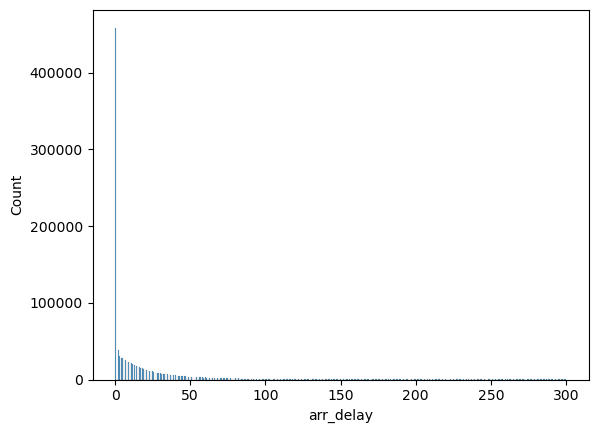

In [16]:
sns.histplot(df_300, x="arr_delay")

This means that most of the train arrives on time. Few train arrived so late.

<Axes: xlabel='arr_delay', ylabel='Count'>

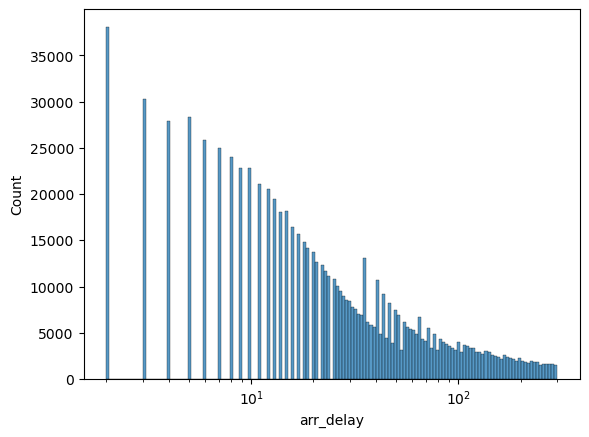

In [17]:
sns.histplot(df_300, x="arr_delay", log_scale=True)

log0 is undefined so that 0 scale is vanished.

In [ ]:
import json

with open("Indian-Railway-Network-and-Delays/stations_zones_mapping.json") as f:
    zones = json.load(f)

len(zones), list(zones.items())[:3]

(4735, [('AADR', 'NR'), ('AAG', 'CR'), ('AAL', 'SECR')])

Integrate stations with the zone.

In [20]:
df["zone"] = df["station"].map(zones)

How many rows has NaN values.

In [24]:
df["zone"].isna().sum()

np.int64(30)

Fetch the unique values of the stations for which the zone is NaN.

In [31]:
df[df["zone"].isna()]["station"].unique()

<ArrowStringArray>
['TMA']
Length: 1, dtype: str

In [32]:
df.groupby("zone")["arr_delay"].agg(["count", "median", "mean"]).sort_values("median", ascending=False)

,count,median,mean
zone,,,
KRCL,19468,45.0,74.212657
NCR,65399,17.0,50.056331
SCR,133960,13.0,37.171910
WCR,70130,12.0,44.073178
CR,92135,10.0,43.571032
ECR,99181,10.0,38.496910
ECOR,62457,10.0,35.833053
SER,42781,9.0,45.058835
SECR,28562,9.0,52.377425


In [41]:
df["zone"].unique()

<ArrowStringArray>
[  'ER',  'ECR',  'NCR',   'NR',  'SCR',   'CR',  'WCR',   'WR',  'NWR',
   'NE',   'SR',  'SER', 'ECOR',  'SWR', 'SECR',  'NFR', 'KRCL',    nan]
Length: 18, dtype: str

<Axes: xlabel='arr_delay', ylabel='zone'>

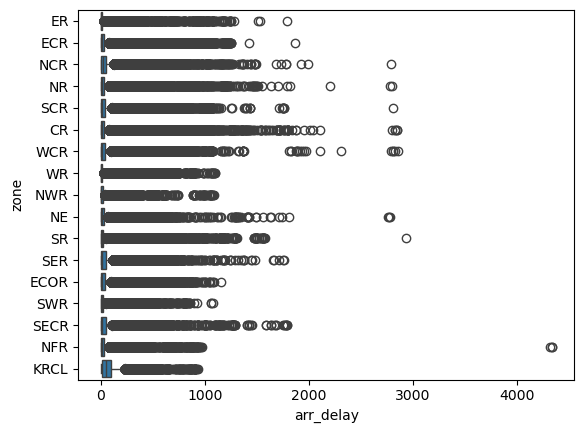

In [43]:
sns.boxplot(df, y="zone", x="arr_delay")

<Axes: xlabel='arr_delay', ylabel='zone'>

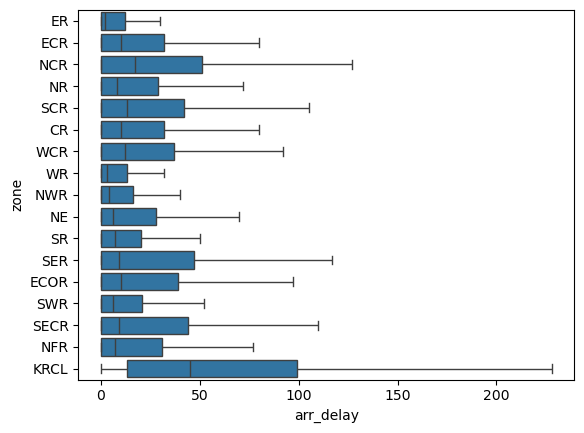

In [44]:
sns.boxplot(df, x="arr_delay", y="zone", showfliers=False)

In [47]:
order = df.groupby("zone")["arr_delay"].median().sort_values(ascending=False).index
order


Index(['KRCL', 'NCR', 'SCR', 'WCR', 'CR', 'ECR', 'ECOR', 'SER', 'SECR', 'NR',
       'NFR', 'SR', 'NE', 'SWR', 'NWR', 'WR', 'ER'],
      dtype='str', name='zone')

<Axes: xlabel='arr_delay', ylabel='zone'>

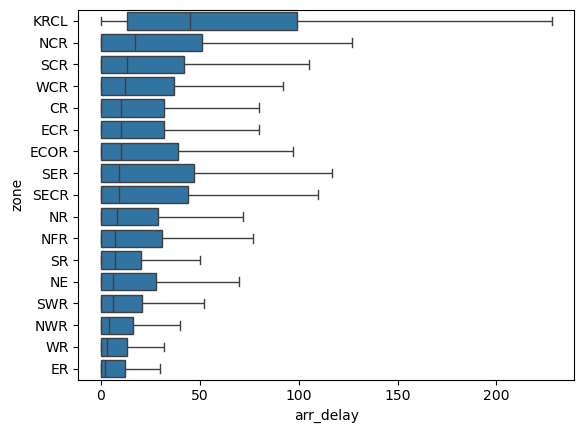

In [48]:
sns.boxplot(df, x="arr_delay", y="zone", showfliers=False, order=order)


The best zone is ER and the worst zone is KRCL. And the Q1, Q2, Q3 all are high in KRCL. THat why it's worst.

In SECR many trains are delayed by 9 or less but few trains have too much delay.

It is a useful feature cz cause if a train is in KRCL then we could have a little bit intuition that train in this regions are usually dealyed.

SECR: median 9 but mean 52, so it has a small number of very large delays."

"KRCL median 45 min vs ER median 2 min, about 20× worse."